# Aperture — 孔径: 圆孔 + 圆柱堵块

本 notebook 是官方算例系列示例之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

二轮审计 (R2-3-1) 重建: 旧算例参考粒子落在 ZSTOP=0.25 m 之后 (test.ini 参考粒子 z=1.9 m),
ASTRA 报 "particle starts behind Zstop"、0 迭代、两个孔径元件从未作用, golden Xemit 仅 1 行
(数值=输入统计原样), 比对 rel=0.0000% 恒真。重建后: 参考粒子回到 z=0、ZSTOP=0.17 m;
探针横向偏移改为 mm 量级 — 3 个探针 (|r|>1.5 mm) 被圆孔 (R=1.5 mm, 水平偏移 +0.5 mm,
@0.10–0.12 m) 刮削, 其余 497 粒子穿过圆孔到达 ZSTOP; 堵块 (负半径) @0.19–0.20 m 位于
ZSTOP 之后, 几何保留在输入卡中 (把 ZSTOP 改回 0.25 m 重跑可观察其拦停全部粒子,
见 examples/Aperture/README.md)。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Aperture"
STEM = "astra"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Aperture | 物理: 孔径: 圆孔 + 圆柱堵块


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                     Astra- A space charge tracking algorithm     
               Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
                              DESY,  Hamburg 2022                 
                         19. 8.2026  21:34

     Parameter file is:  astra.in                                          
     Aperture test - circular + beam stop                                            

 Initialize element settings:
     neglecting space charge forces 

 --------------------------------------------------------------------------
 Aperture:

 --------------------------------------------------------------------------
     500 particles from file test.ini                                          

     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =    -5.7355E-05 mm
     vertical beam positio

In [4]:
# ===== 运行护栏 (R2-3-1): 真正检验 "粒子损失于孔径" =====
# 旧算例 0 迭代时 Xemit 仅 1 行且 lost=0, 比对恒真; 这里对
# 运行产物做硬断言: 迭代>0、Xemit 多行且末行 z 到达 ZSTOP、
# 相空间末 dump 中 3 个粒子以 lost-on-aperture 状态 (-17) 消失。
from astra_tools.io.astra_emit import parse_output_file
from astra_tools.io import read_distribution
from astra_tools.namelist.parse import parse_namelists
import numpy as np

ph = phase_files(work, STEM)
zstop = float(np.asarray(parse_namelists(
    PROJECT_ROOT / "examples/Aperture/astra.in")["OUTPUT"]["ZSTOP"]).ravel()[0])
emit = parse_output_file(work / "astra.Xemit.001")
z_arr = np.asarray(emit["mean_z"])
assert len(z_arr) > 1, "Xemit 必须多行 (护栏)"
assert abs(float(z_arr[-1]) - zstop) / zstop < 0.005, "末行 z 必须到达 ZSTOP (护栏)"
dist_last = read_distribution(ph[-1])
n_lost = dist_last.n_particle - dist_last.n_active
assert n_lost == 3, "圆孔应刮削 3 个 mm 级偏移探针, 实际 lost=%d" % n_lost
print("护栏通过: Xemit 行数=%d, 末行 z=%.4f m == ZSTOP=%.4f m,"
      " 相空间末 dump 损失粒子=%d (flag -17 = lost on aperture)"
      % (len(z_arr), float(z_arr[-1]), zstop, n_lost))

护栏通过: Xemit 行数=500, 末行 z=0.1700 m == ZSTOP=0.1700 m, 相空间末 dump 损失粒子=3 (flag -17 = lost on aperture)


In [5]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: astra.0017.001

  Aperture @ astra.0017.001
  Particles:            500 total,      497 active,      0 passive,
                         3 lost,      0 not started
  Total charge:        0.9940 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:     250.5100 MeV/c
  Ref. kinetic E:    249.9995 MeV
  gamma:             490.2369
  beta:              0.999998
----------------------------------------
  Centroid x:         -0.0004 mm
  Centroid y:          0.0056 mm
  Centroid z:        169.9980 mm
  sigma_x:             0.0855 mm
  sigma_y:             0.0805 mm
  sigma_z:             0.9282 mm
----------------------------------------
  Mean pz:           250.5100 MeV/c
  sigma_p/p:         0.000008
  Mean E_kin:        249.9995 MeV
  sigma_E:             2.1129 keV
  sigma_E/E:         0.000008
----------------------------------------
  eps_x (geom):        0.0017 um.rad
  eps_y (geom):        0.0016 um.rad
  eps_nx:              0.8389 um

quantity,value,unit
n_particle,500,
n_active,497,
n_passive,0,
n_lost,3,
n_not_started,0,
total_charge_nC,0.994 (|Q|),nC
mean_x_mm,-0.00038642,mm
mean_y_mm,0.00555155,mm
mean_z_mm,169.998,mm
sig_x_mm,0.0855308,mm


### 示例要点

&APERTURE namelist 定义孔径元件 (Ap_Z1/Ap_Z2/Ap_R, 单位 mm, 负半径 = 堵块)。本算例:

- 圆孔: R=1.5 mm、水平偏移 +0.5 mm, @ 0.10–0.12 m — 刮削满足
  sqrt((x−0.5mm)²+y²) > 1.5 mm 的粒子, 本例为 3 个 mm 级偏移探针 (P1/P2/P3);
- 堵块: 负半径 @ 0.19–0.20 m — 位于 ZSTOP=0.17 m 之后, 会拦停穿圆孔的
  全部粒子 (改 ZSTOP=0.25 m 重跑可见 "particles lost on aperture = 500");
- 束包络 sigma_x 在圆孔处从 ~158 μm 降到 ~86 μm, 叠图可见孔径作用。

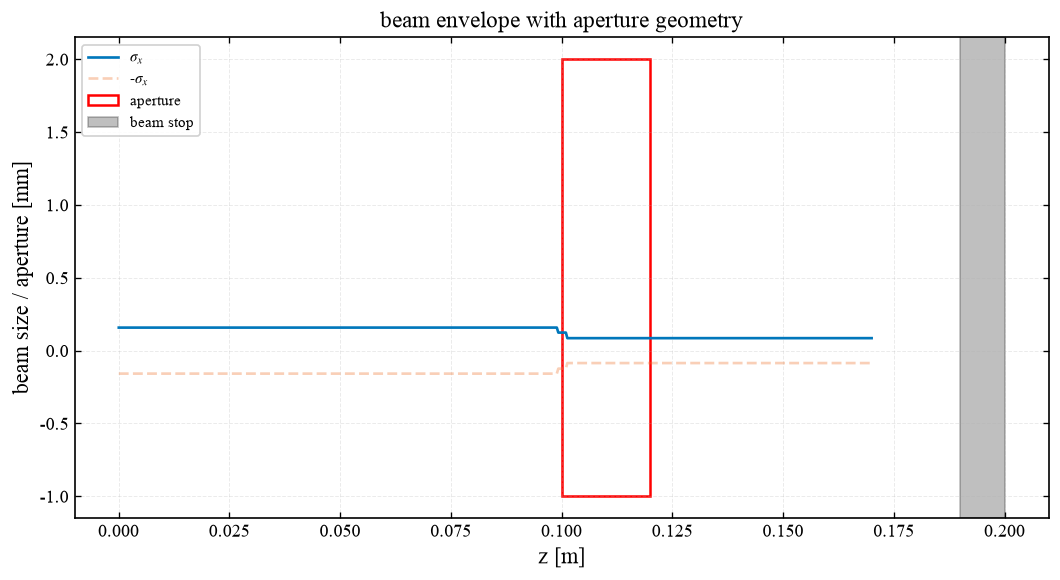

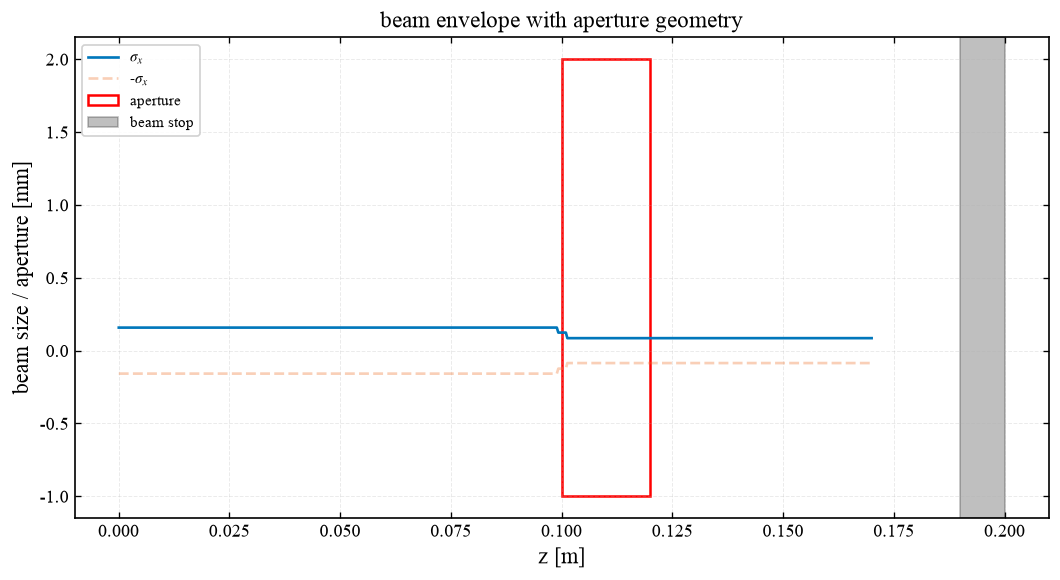

In [6]:
from astra_tools.namelist.parse import parse_namelists
from astra_tools.io.astra_emit import read_emit_files
from astra_tools.plot.advanced_plots import (
    aperture_elements, plot_envelope_with_aperture)
ap = parse_namelists(PROJECT_ROOT / "examples/Aperture/astra.in")["APERTURE"]
emit_ap = read_emit_files(str(work / STEM))
plot_envelope_with_aperture(emit_ap, aperture_elements(ap))

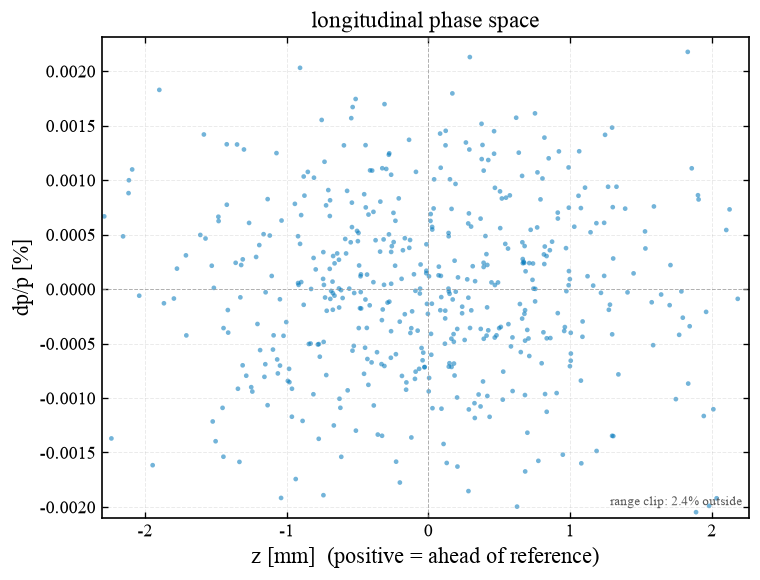

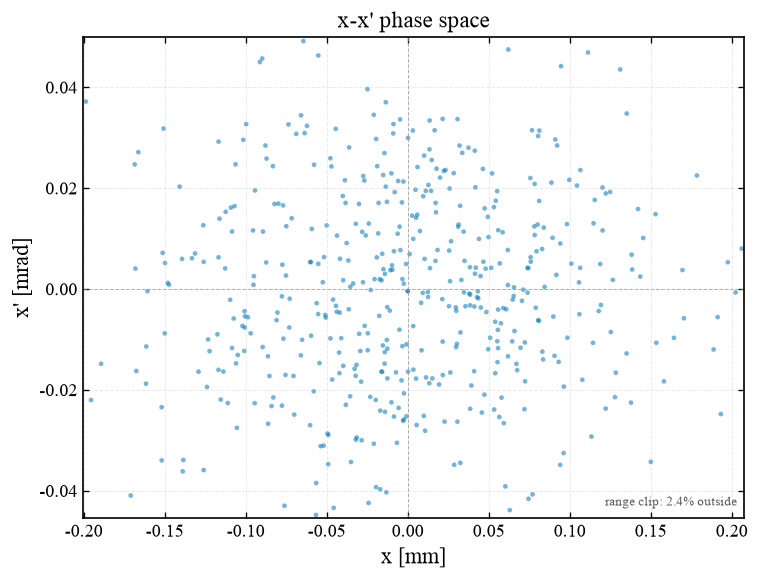

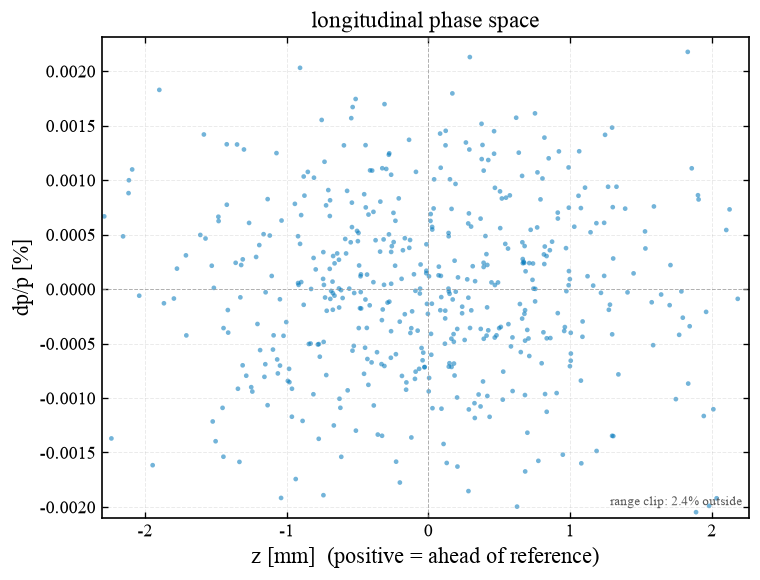

In [7]:
from astra_tools.plot.phase_space import plot_phase_space
plot_phase_space(dist, plane="x")
plot_phase_space(dist, plane="z")

In [8]:
# ===== 黄金比对 (护栏 + rel < 0.5% 判 OK) =====
assert compare_xemit(NAME, work), "黄金比对未通过 (护栏 R2-3-1)"
print("其他官方算例的示例 notebook 同样位于 examples/ 目录")

  护栏: Xemit 行数 new=500 golden=500
  护栏: 末行 z=0.17 vs ZSTOP=0.17 (rel=0.0000%)
  末行比对 (new vs golden):
    norm_emit_x    8.3887e-07 8.3887e-07 rel=0.0000% OK
    sigma_x        8.5531e-05 8.5531e-05 rel=0.0000% OK
    mean_z         0.17       0.17       rel=0.0000% OK
  总体: OK
其他官方算例的示例 notebook 同样位于 examples/ 目录
